In [27]:
#Import libaries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import calendar as cal

In [28]:
#Import dataset
csv = 'synthetic_dataset.csv'
dataset = pd.read_csv(csv)
print('Sucess!')

Sucess!


In [29]:
#Check information about the dataset
print(dataset.info())
print(dataset.dtypes)
print(dataset.describe())
print(dataset.shape)

<class 'pandas.DataFrame'>
RangeIndex: 4362 entries, 0 to 4361
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  1614 non-null   str    
 1   Price     4188 non-null   float64
 2   Rating    2312 non-null   float64
 3   Stock     3010 non-null   str    
 4   Discount  3970 non-null   float64
dtypes: float64(3), str(2)
memory usage: 170.5 KB
None
Category        str
Price       float64
Rating      float64
Stock           str
Discount    float64
dtype: object
             Price       Rating     Discount
count  4188.000000  2312.000000  3970.000000
mean   5016.970630     3.038293    24.516625
std    2839.984813     1.143074    14.347164
min     102.000000     1.000366     0.000000
25%    2628.250000     2.069490    12.000000
50%    4996.500000     3.082060    25.000000
75%    7418.000000     4.008620    37.000000
max    9999.000000     4.997818    49.000000
(4362, 5)


In [30]:
#We saw that the dataset has missing and null values, we also want to check for duplicates.
print(dataset.isnull().sum())
print(dataset.duplicated().sum())

Category    2748
Price        174
Rating      2050
Stock       1352
Discount     392
dtype: int64
15


In [31]:
#We shall remove duplicates first
dataset = dataset.drop_duplicates(keep='first')
print(dataset.duplicated().sum())

0


In [47]:
#Now we shall convert all float objects into the average of the column and all string objects into the mode of the column.
for col in dataset.columns:
    if dataset[col].dtype == 'float64':
        dataset[col] = dataset[col].fillna(dataset[col].mean())
    elif dataset[col].dtype == 'object':
        dataset[col] = dataset[col].fillna(dataset[col].mode()[0])
#Check if there are any missing values left
print(dataset.isnull().sum())

Category    0
Price       0
Rating      0
Stock       0
Discount    0
dtype: int64


In [48]:
#The Catagory column is a string object, we shall convert it into a string type and fill any missing values with 'Unknown'.
dataset['Category'] = dataset['Category'].astype("string")
dataset['Category'] = dataset['Category'].fillna('Unknown')
#The Stock column is also a string so we shall convert it into a string type and fill any missing values with 'Out of Stock'.
dataset['Stock'] = dataset['Stock'].astype("string")
dataset['Stock'] = dataset['Stock'].fillna('Out of Stock')
#Check our cleaning
print(dataset.isnull().sum())

Category    0
Price       0
Rating      0
Stock       0
Discount    0
dtype: int64


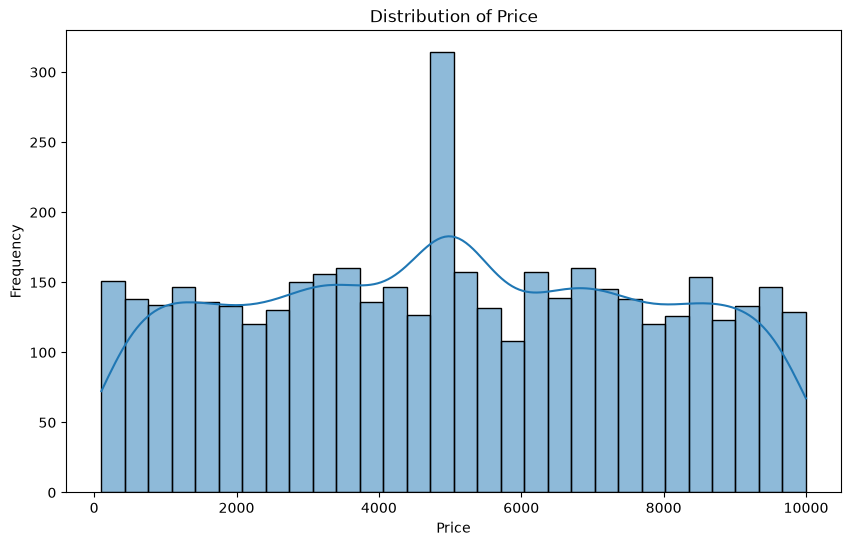

In [49]:
#We can start some analysis on the dataset. We will start by checking the distribution of the Price column. We will use a histogram to visualize the distribution.
plt.figure(figsize=(10,6))
sns.histplot(dataset['Price'], bins=30, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


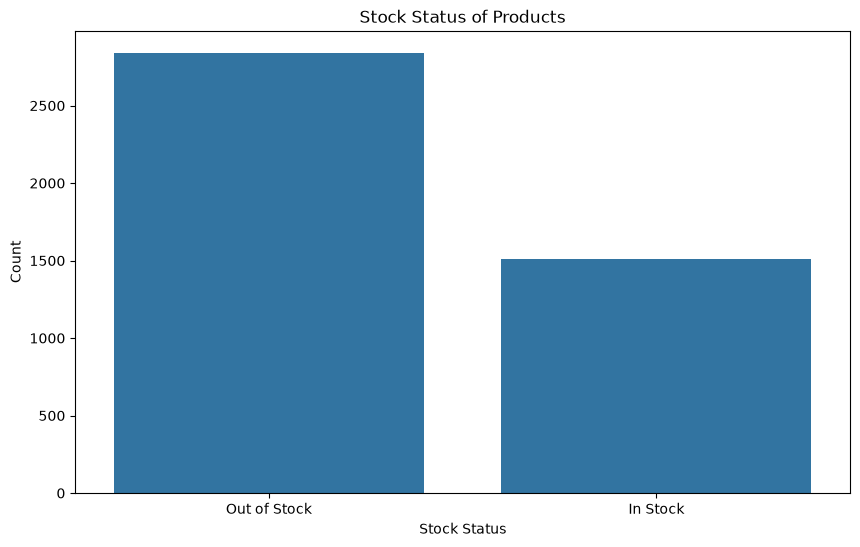

In [50]:
#Checking the stock status of the products in the dataset. We will use a countplot to visualize the stock status.
plt.figure(figsize=(10,6))
sns.countplot(x='Stock', data=dataset)
plt.title('Stock Status of Products')
plt.xlabel('Stock Status')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_11194/2491779026.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Category', data=filtered_data, palette=category_colors, order=filtered_data['Category'].value_counts().index)


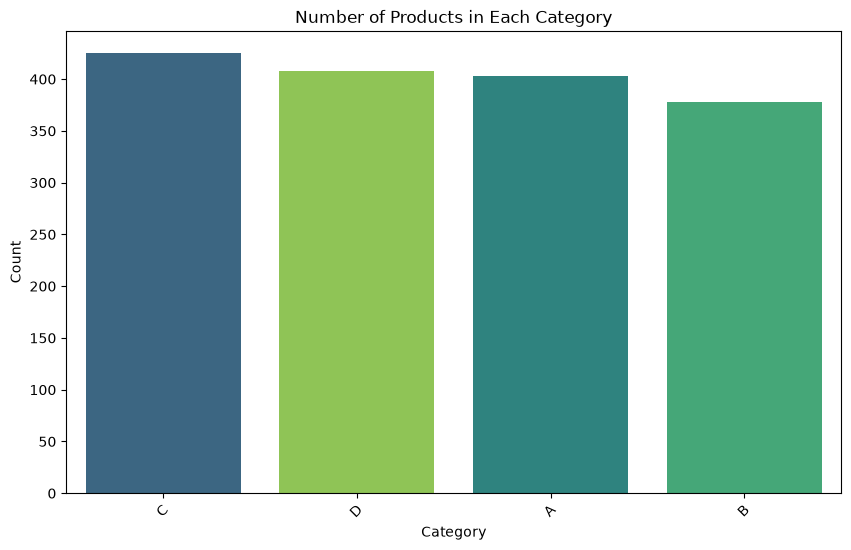

In [57]:
#Check which catagory has the highest number of products. We will ignore the unknown category. We will use a countplot to visualize the number of products in each category, and ensure the colours of the catagories remain consistent with future visualizations.
categories = dataset["Category"].unique()
color_palette = sns.color_palette("viridis", len(categories))
category_colors = dict(zip(categories, color_palette))

plt.figure(figsize=(10,6))
filtered_data = dataset[dataset['Category'] != 'Unknown']
sns.countplot(x='Category', data=filtered_data, palette=category_colors, order=filtered_data['Category'].value_counts().index)
plt.title('Number of Products in Each Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

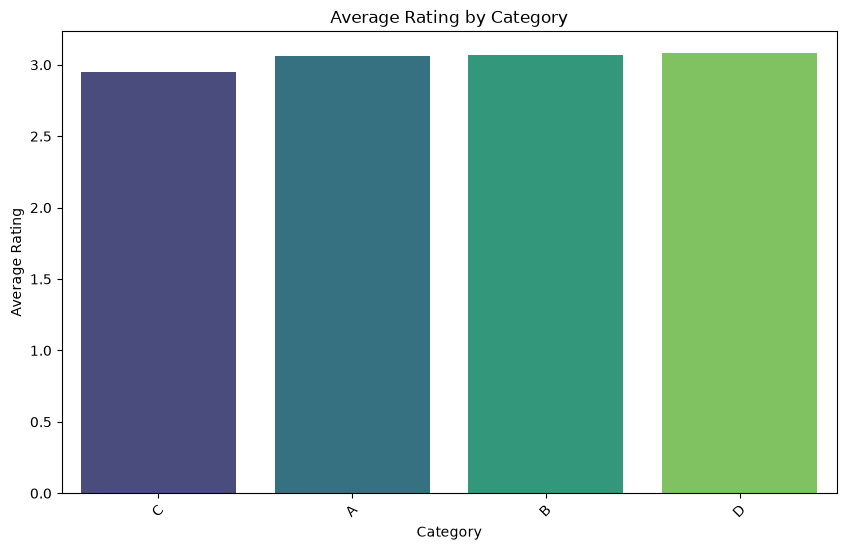

In [58]:
#Check which catagory has the highest rating, we shall ignore the unknown category. We will use a scatterplot to visualize the ratings of each category.
plt.figure(figsize=(10, 6))
filtered_data = dataset[dataset['Category'] != 'Unknown']

sns.barplot(x='Category', y='Rating', data=filtered_data, estimator='mean', errorbar=None, palette='viridis', hue='Category', legend=False)
plt.title('Average Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

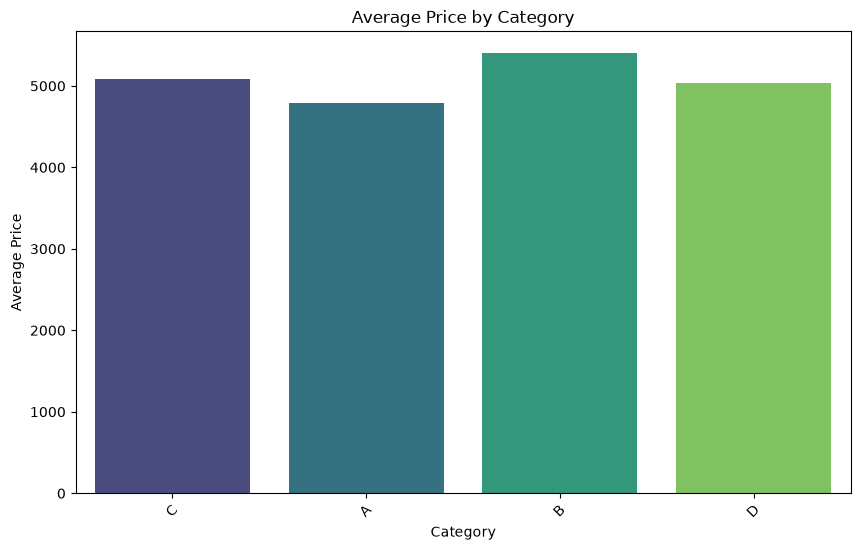

In [59]:
#Looking at the average price of products in each category, we will use a barplot to visualize the average price of products in each category.
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Price', data=filtered_data, estimator='mean', errorbar=None, palette='viridis', hue='Category', legend=False)
plt.title('Average Price by Category')
plt.xlabel('Category')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

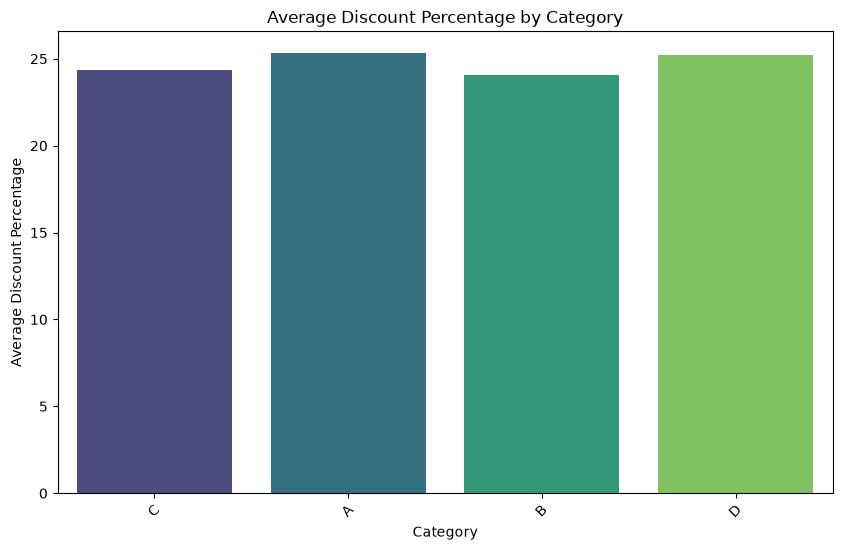

In [61]:
#Cheking the discount percentage of price and catagory, we will use a barplot to visualize the average discount percentage of products in each category.
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Discount', data=filtered_data, estimator='mean', errorbar=None, palette='viridis', hue='Category', legend=False)
plt.title('Average Discount Percentage by Category')
plt.xlabel('Category')
plt.ylabel('Average Discount Percentage')
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='Discount_Bin', ylabel='Rating'>

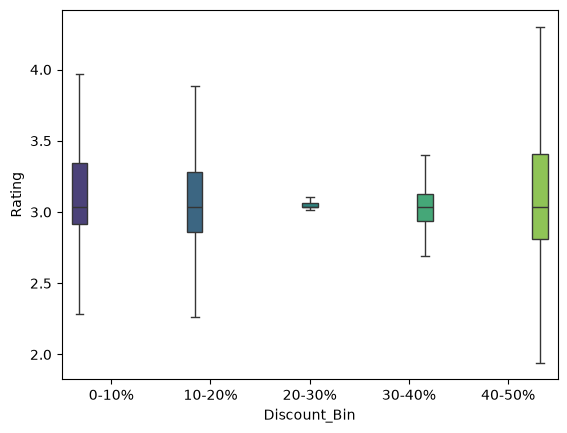

In [68]:
#Checking discount percentage against rating, we will use a scatterplot to visualize the relationship between discount percentage and rating.
filtered_data['Discount_Bin'] = pd.cut(
    filtered_data['Discount'], 
    bins=[0, 10, 20, 30, 40, 50], 
    labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%']
)

sns.boxplot(
    data=filtered_data, 
    x='Discount_Bin', 
    y='Rating', 
    hue='Discount_Bin', 
    palette='viridis', 
    legend=False,
    showfliers=False  # Hides all the individual outlier points
)

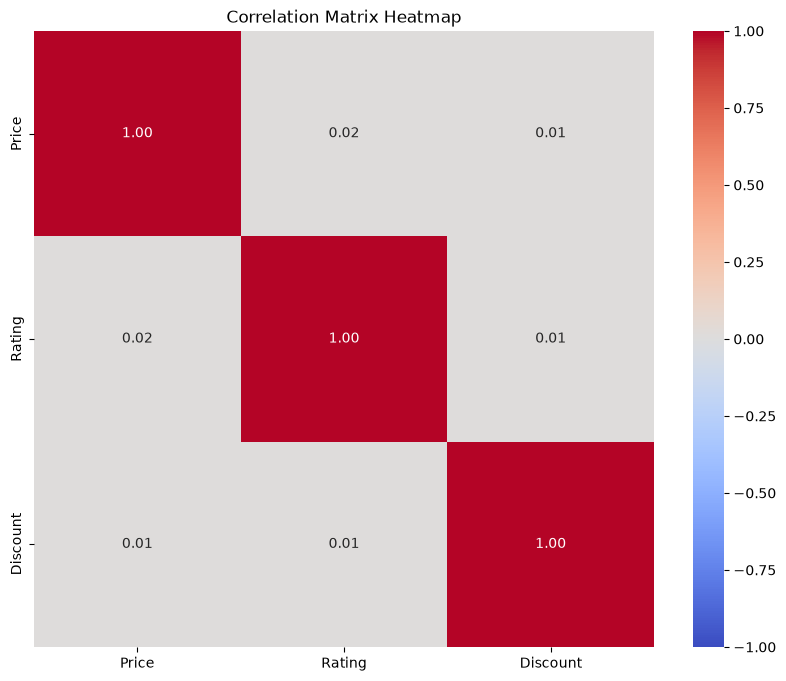

In [63]:
#looking at Pearson values

plt.figure(figsize=(10, 8))


sns.heatmap(
    corr_matrix, 
    annot=True,    
    fmt=".2f",   
    cmap='coolwarm', 
    vmin=-1, vmax=1
)

plt.title('Correlation Matrix Heatmap')
plt.show()